재방문 고객 비중이 지난달 대비 30% 이상 감소한 경우 1로 표시 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [3]:
df = pd.read_csv('df_3targets.csv')
df.replace(-999999.9, np.nan, inplace=True)

In [4]:
y = df['target2_loyalty_drop']
X = df.drop(columns=['target1_sales_drop', 'target2_loyalty_drop', 'target3_relative_decline'])

In [5]:
cols_to_drop = [
        'ENCODED_MCT', 'TA_YM', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'ARE_D', 'MCT_ME_D', 'is_closed',
        'RC_M1_SAA', 'sales_level'
    ]
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])


In [6]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
X[numerical_features] = imputer.fit_transform(X[numerical_features])
X = pd.get_dummies(X, columns=categorical_features, dummy_na=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [9]:
model_target2 = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

In [10]:
model_target2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
y_pred = model_target2.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '고객이탈 (1)']))
    

              precision    recall  f1-score   support

      정상 (0)       0.99      0.99      0.99     17153
    고객이탈 (1)       0.21      0.42      0.28       165

    accuracy                           0.98     17318
   macro avg       0.60      0.70      0.64     17318
weighted avg       0.99      0.98      0.98     17318



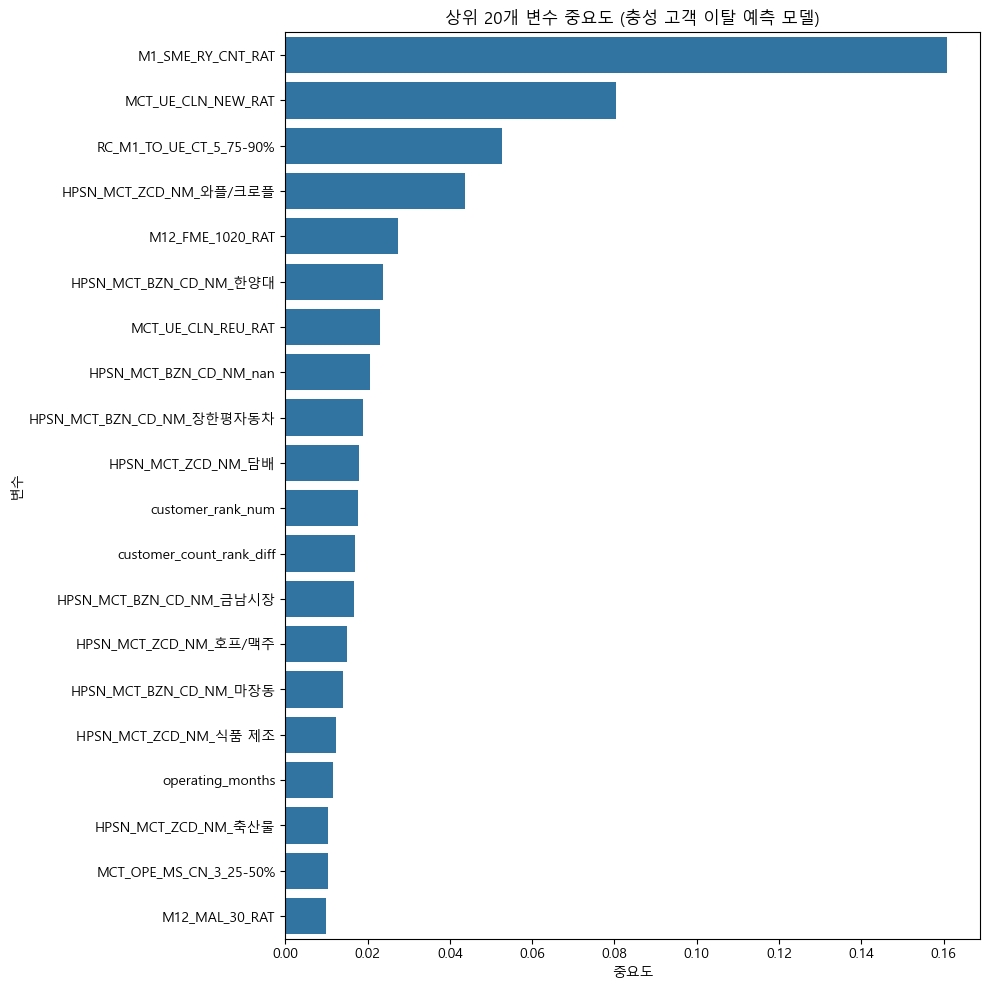

In [12]:
feature_importances = pd.Series(model_target2.feature_importances_, index=X.columns).sort_values(ascending=False)
    
plt.figure(figsize=(10, 10))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title('상위 20개 변수 중요도 (충성 고객 이탈 예측 모델)')
plt.xlabel('중요도')
plt.ylabel('변수')
plt.tight_layout()
plt.show()


In [13]:

# 1. 학습된 모델(model)에서 변수 중요도 정보 가져오기
feature_importances = pd.Series(model_target2.feature_importances_, index=X.columns)

# 2. 중요도 순으로 정렬하고 상위 15개 선택
N = 15
top_n_features = feature_importances.sort_values(ascending=False).head(N)

print(f"---  '매출 급락' 예측 핵심 변수 TOP {N} ---")
print(top_n_features)

# 3. 선택된 변수들의 이름을 리스트로 저장
#    이 리스트를 다음 모델 학습에 바로 사용할 수 있습니다.
list_of_top_n_features = top_n_features.index.tolist()
print("\n--- 다음 모델링에 사용할 변수 목록 ---")
print(list_of_top_n_features)

---  '매출 급락' 예측 핵심 변수 TOP 15 ---
M1_SME_RY_CNT_RAT            0.160822
MCT_UE_CLN_NEW_RAT           0.080446
RC_M1_TO_UE_CT_5_75-90%      0.052709
HPSN_MCT_ZCD_NM_와플/크로플       0.043754
M12_FME_1020_RAT             0.027507
HPSN_MCT_BZN_CD_NM_한양대       0.023851
MCT_UE_CLN_REU_RAT           0.023089
HPSN_MCT_BZN_CD_NM_nan       0.020628
HPSN_MCT_BZN_CD_NM_장한평자동차    0.018877
HPSN_MCT_ZCD_NM_담배           0.017853
customer_rank_num            0.017784
customer_count_rank_diff     0.016886
HPSN_MCT_BZN_CD_NM_금남시장      0.016640
HPSN_MCT_ZCD_NM_호프/맥주        0.014910
HPSN_MCT_BZN_CD_NM_마장동       0.014106
dtype: float32

--- 다음 모델링에 사용할 변수 목록 ---
['M1_SME_RY_CNT_RAT', 'MCT_UE_CLN_NEW_RAT', 'RC_M1_TO_UE_CT_5_75-90%', 'HPSN_MCT_ZCD_NM_와플/크로플', 'M12_FME_1020_RAT', 'HPSN_MCT_BZN_CD_NM_한양대', 'MCT_UE_CLN_REU_RAT', 'HPSN_MCT_BZN_CD_NM_nan', 'HPSN_MCT_BZN_CD_NM_장한평자동차', 'HPSN_MCT_ZCD_NM_담배', 'customer_rank_num', 'customer_count_rank_diff', 'HPSN_MCT_BZN_CD_NM_금남시장', 'HPSN_MCT_ZCD_NM_호프/맥주', 'HPSN_MCT_BZ

In [14]:
final_top_features = [col for col in list_of_top_n_features if col in X.columns]
X_simple = X[final_top_features]
print(f"\n✅ 핵심 변수 {len(X_simple.columns)}개를 선택하여 '단순 모델'을 준비했습니다.")


✅ 핵심 변수 15개를 선택하여 '단순 모델'을 준비했습니다.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
model_simple = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

In [16]:
model_simple.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
y_pred = model_simple.predict(X_test)
print("\n--- 📊 '단순 모델' 성능 평가 (Top 15 변수 사용) ---")
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '충성고객 감소 (1)']))


--- 📊 '단순 모델' 성능 평가 (Top 15 변수 사용) ---
              precision    recall  f1-score   support

      정상 (0)       1.00      0.96      0.98     17153
 충성고객 감소 (1)       0.12      0.59      0.20       165

    accuracy                           0.96     17318
   macro avg       0.56      0.78      0.59     17318
weighted avg       0.99      0.96      0.97     17318



In [18]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV


In [19]:
list_of_top_features_target2 = [
    'M1_SME_RY_CNT_RAT', 'MCT_UE_CLN_NEW_RAT', 'RC_M1_TO_UE_CT_5_75-90%', 'HPSN_MCT_ZCD_NM_와플/크로플', 'M12_FME_1020_RAT', 'HPSN_MCT_BZN_CD_NM_한양대', 'MCT_UE_CLN_REU_RAT', 'HPSN_MCT_BZN_CD_NM_nan', 'HPSN_MCT_BZN_CD_NM_장한평자동차', 'HPSN_MCT_ZCD_NM_담배', 'customer_rank_num', 'customer_count_rank_diff', 'HPSN_MCT_BZN_CD_NM_금남시장', 'HPSN_MCT_ZCD_NM_호프/맥주', 'HPSN_MCT_BZN_CD_NM_마장동'
]

In [20]:
df = pd.read_csv('df_3targets.csv')
df.replace(-999999.9, np.nan, inplace=True)

In [21]:
y = df['target2_loyalty_drop'] # 타겟 변경
X = df.drop(columns=['target1_sales_drop', 'target2_loyalty_drop', 'target3_relative_decline'])
    

In [22]:
cols_to_drop = [
        'ENCODED_MCT', 'TA_YM', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'ARE_D', 'MCT_ME_D', 'is_closed',
        'RC_M1_SAA', 'sales_level'
    ]
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])

In [23]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
X[numerical_features] = imputer.fit_transform(X[numerical_features])
X = pd.get_dummies(X, columns=categorical_features, dummy_na=True)


In [24]:
final_top_features = [col for col in list_of_top_features_target2 if col in X.columns]
X_simple = X[final_top_features]
print(f"\n핵심 변수 {len(X_simple.columns)}개를 선택하여 튜닝을 준비합니다.")


핵심 변수 15개를 선택하여 튜닝을 준비합니다.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42, stratify=y)
    
param_dist = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    }

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42)
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=20, scoring='f1', cv=3, random_state=42, n_jobs=-1, verbose=1)

In [26]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [27]:
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [28]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '고객이탈 (1)']))

              precision    recall  f1-score   support

      정상 (0)       1.00      0.93      0.96     17153
    고객이탈 (1)       0.10      0.79      0.18       165

    accuracy                           0.93     17318
   macro avg       0.55      0.86      0.57     17318
weighted avg       0.99      0.93      0.96     17318

